In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import joblib
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../Datasets/liver.csv")

df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
df.shape

(583, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [5]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [6]:
nulls = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage":
    round(df.isnull().mean()*100,2)
})

nulls.sort_values(by="Missing",ascending=False)

,Missing,Percentage
Albumin_and_Globulin_Ratio,4,0.69
Age,0,0.00
Gender,0,0.00
Total_Bilirubin,0,0.00
Direct_Bilirubin,0,0.00
Alkaline_Phosphotase,0,0.00
Alamine_Aminotransferase,0,0.00
Aspartate_Aminotransferase,0,0.00
Total_Protiens,0,0.00
Albumin,0,0.00


In [12]:
df['Dataset'] = df['Dataset'].replace({1:1,2:0})

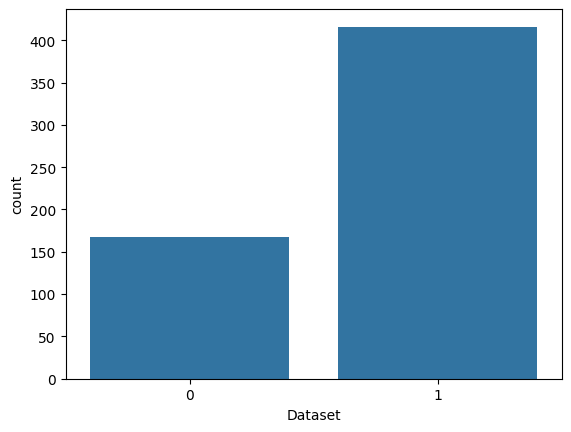

In [13]:
sns.countplot(x='Dataset', data=df)
plt.show()

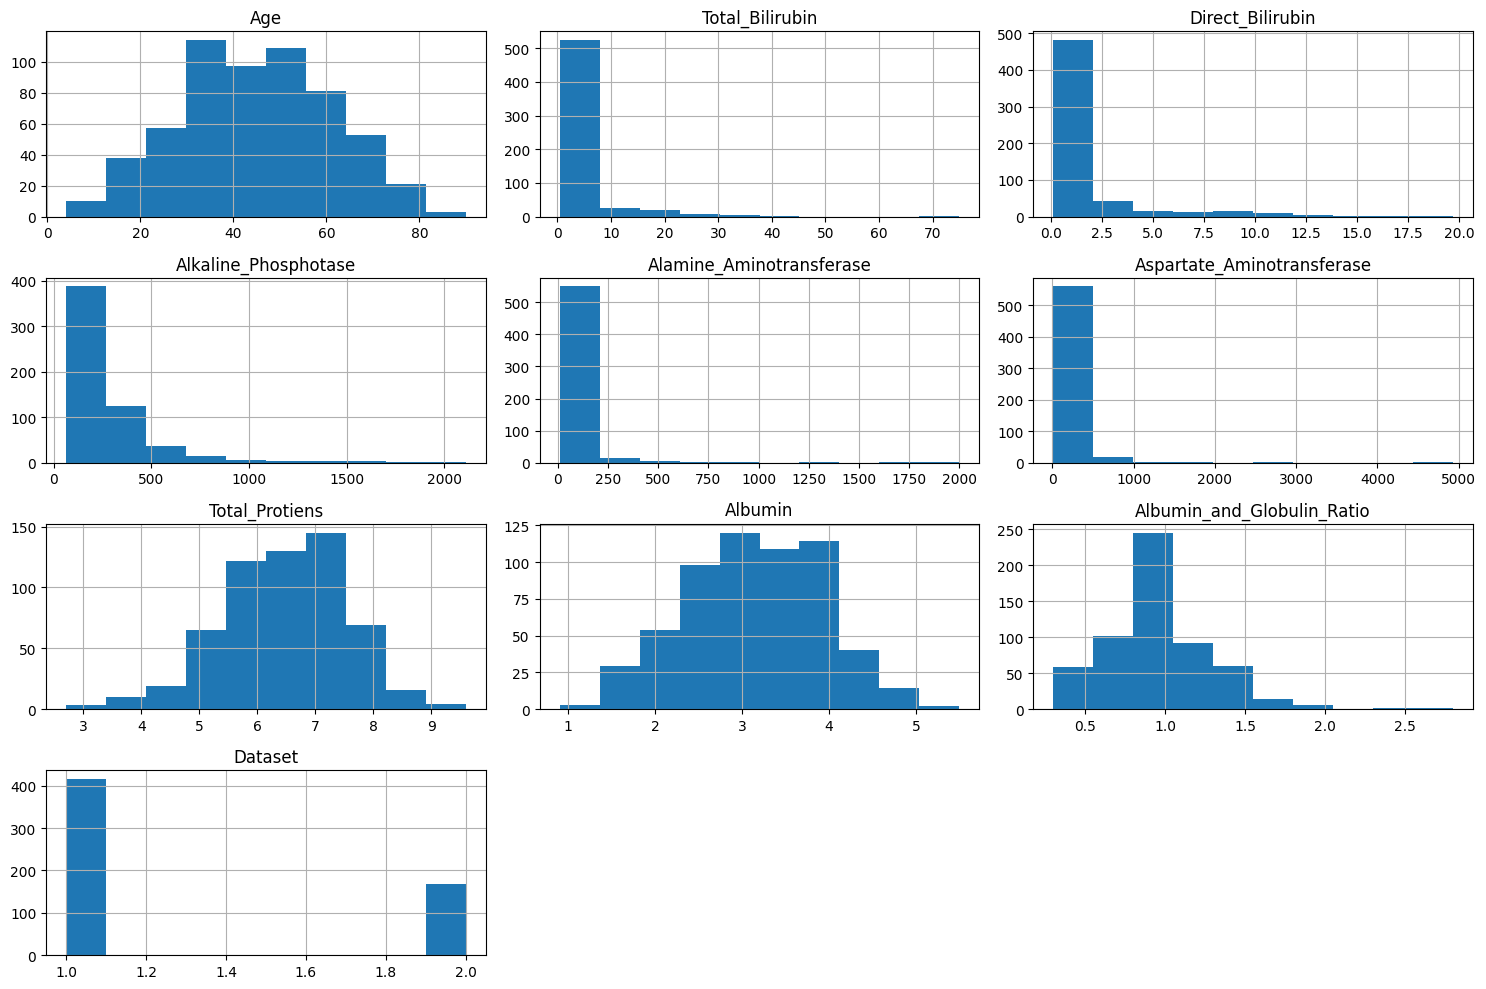

In [8]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

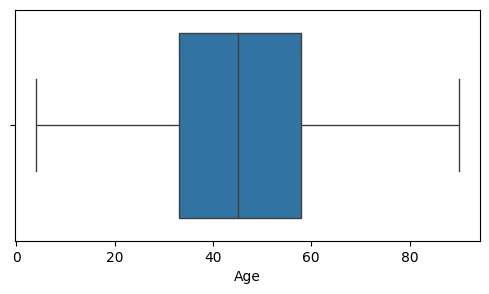

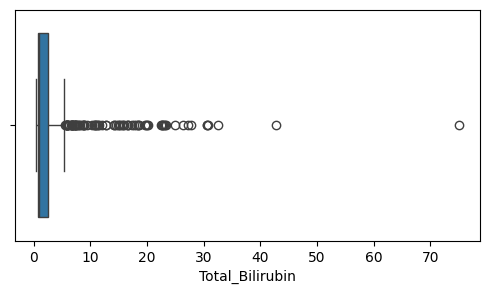

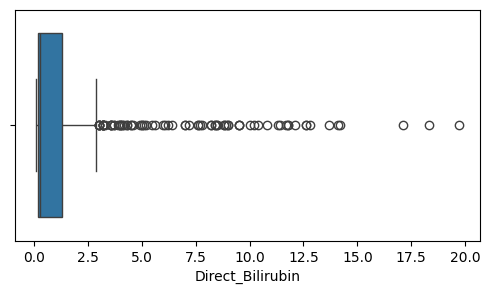

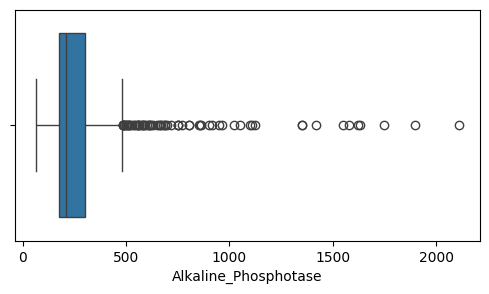

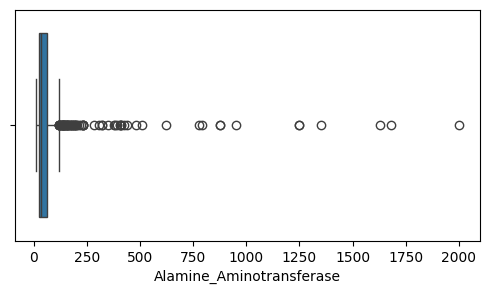

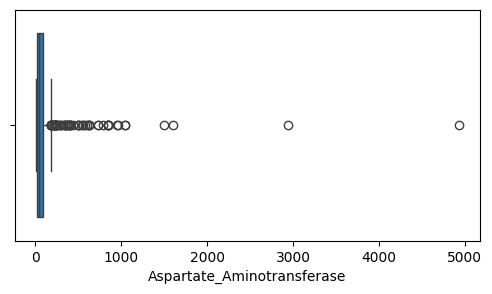

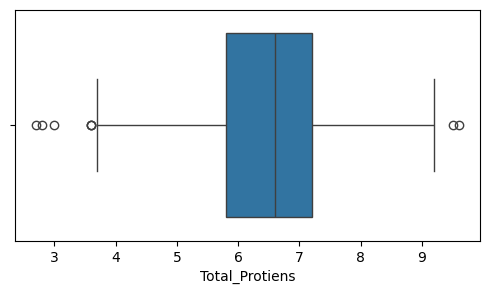

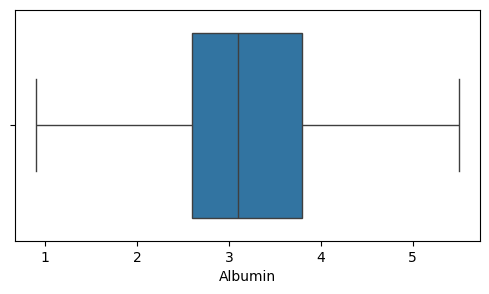

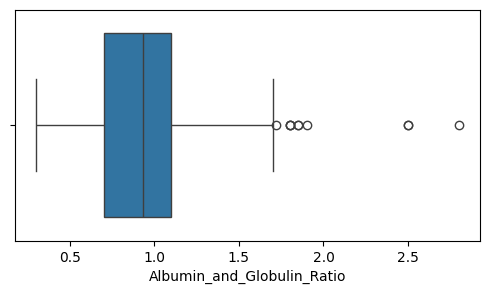

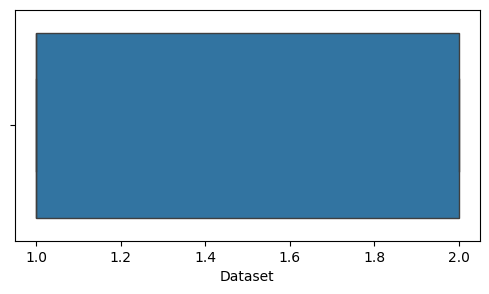

In [10]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.show()

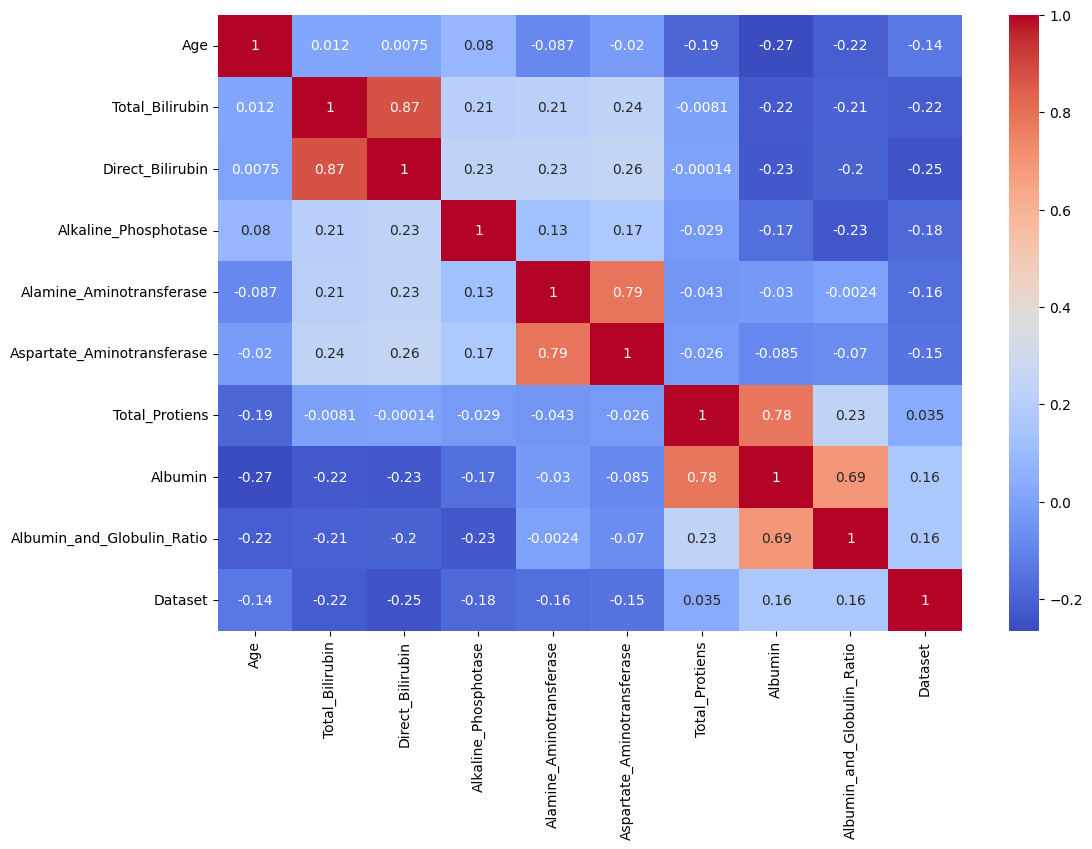

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

plt.show()

In [14]:
X = df.drop('Dataset', axis=1)
y = df['Dataset']

In [15]:
cat_cols = ['Gender']

num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

In [16]:
numeric_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [17]:
categorical_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

In [18]:
preprocessor = ColumnTransformer([
    ('num',numeric_transformer,num_cols),
    ('cat',categorical_transformer,cat_cols)
])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',LogisticRegression(max_iter=2000))
])

lr_pipeline.fit(X_train, y_train)

pred_lr = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test,pred_lr)

print(lr_acc)

0.7350427350427351


In [23]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',RandomForestClassifier(n_estimators=300,random_state=42))
])

rf_pipeline.fit(X_train,y_train)

pred_rf = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test,pred_rf)

print(rf_acc)

0.7350427350427351


In [25]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',XGBClassifier(
         n_estimators=500,
         max_depth=4,
         learning_rate=0.03,
         random_state=42,
     ))
])

xgb_pipeline.fit(X_train,y_train)

pred_xgb = xgb_pipeline.predict(X_test)

xgb_acc = accuracy_score(y_test,pred_xgb)

print(xgb_acc)

0.7008547008547008


In [26]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[lr_acc,rf_acc,xgb_acc]
})

results.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy
0,Logistic Regression,0.735043
1,Random Forest,0.735043
2,XGBoost,0.700855


In [27]:
joblib.dump(
    lr_pipeline,
    "liver_model.pkl"
)

['liver_model.pkl']